# Mamba-MPC on the Quanser Aero2

Companion code for *Mamba Sequence Modeling Meets Model Predictive Control*
(Cevaal, de Jong, Lazar), IEEE Open Journal of Control Systems, 2026.

The Aero2 is the paper's physical validation: a two-degree-of-freedom
pitch-and-yaw rig controlled at 40 Hz, with the Mamba predictor embedded in the
optimiser exactly as in the numerical examples.

**This notebook requires the hardware.** Cells 7 and 10 talk to the rig through
the Quanser SDK and cannot run without it. The stored outputs below are from the
original experiment and are the record of that run.

The model definition, its CasADi translation and the MPC problem now come from
the shared `mambampc` package rather than a local copy. That migration is
verified rather than assumed: `tests/test_casadi_equivalence.py` checks the
CasADi and PyTorch models agree to ~1e-15 on every Aero2 checkpoint, and the
optimisation problem and its bounds were confirmed identical to the original
formulation before the change was made.


#### Import Packages

In [1]:
import os
import sys
import pathlib

# Make the repository root importable without installing the package.
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))

import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from mambampc.models.pscan import pscan
from mambampc.models import Mamba, MambaConfig, MambaMPC
from mambampc.mpc import setup_mpc
from mambampc.data import HankelMatrices, HankelMatricesStates, HankelMatricesSequences, Sequence2Sequence, Sequence2SequenceStates
from mambampc.data import BestModelSaver
from mambampc.plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mambampc.systems import multisine

In [ ]:
#Aero 2 system 
from pal.products.aero2 import Aero2
from pal.utilities.math import SignalGenerator, wrap_to_2pi
from pal.utilities.scope import Scope, MultiScope

torch.set_default_dtype(torch.float64)

## Generate Training Data

In [3]:
def generate_prbs(amplitude, freq_range, num_samples):
    """
    Generates two Pseudo-Random Binary Sequences (PRBS).

    A PRBS is a signal that switches between a high (+amplitude) and low
    (-amplitude) state at random intervals.

    Args:
        amplitude (float or int): The magnitude of the signal's high/low states.
        freq_range (list or tuple): A list [min, max] that defines the random
                                    duration (in samples) for each state.
        num_samples (int): The total length of the output signal array.

    Returns:
        tuple: A tuple containing two numpy arrays, (prbs1, prbs2).
    """
    # --- Generate Switching Points for Two Signals ---

    # 1. Create random durations for each signal state
    durations1 = np.random.uniform(freq_range[0], freq_range[1], num_samples).round().astype(int)
    durations2 = np.random.uniform(freq_range[0], freq_range[1], num_samples).round().astype(int)

    # 2. Calculate the specific sample number where the signal changes state
    # This is done by taking the cumulative sum of the random durations.
    switch_points1 = np.cumsum(durations1)
    switch_points2 = np.cumsum(durations2)

    # --- Create the Amplitude Sequence ---
    # This array holds the alternating values (+amp, -amp, +amp, ...)
    # that the signal will switch between.
    alternating_amps = np.zeros(num_samples)
    alternating_amps[0::2] = amplitude   # Set even indices to +amplitude
    alternating_amps[1::2] = -amplitude  # Set odd indices to -amplitude

    # --- Build the Final PRBS Signals ---
    prbs1 = np.zeros(num_samples)
    prbs2 = np.zeros(num_samples)

    # For each calculated switch point, fill the signal array from that
    # point onward with the next value from the alternating amplitude sequence.
    for i, switch_time in enumerate(switch_points1):
        if switch_time < num_samples:
            prbs1[switch_time:] = alternating_amps[i]
        else:
            break # Stop if switch points go beyond the signal length

    for i, switch_time in enumerate(switch_points2):
        if switch_time < num_samples:
            prbs2[switch_time:] = alternating_amps[i]
        else:
            break

    return prbs1, prbs2

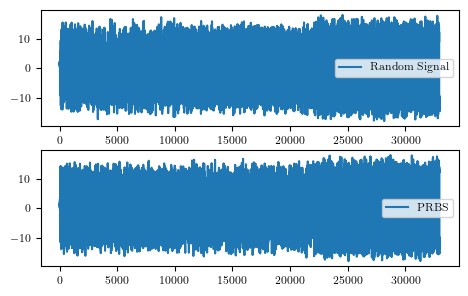

In [4]:
nstep = 11000

u_data1_MS = 3*multisine(N_points_per_period=nstep, N_periods=1, pmin=1, pmax=1000, n_crest_factor_optim=100,seed=None)
u_data2_MS = 3*multisine(N_points_per_period=nstep, N_periods=1, pmin=1, pmax=1000, n_crest_factor_optim=100,seed=None)

u_data3_MS = 2*multisine(N_points_per_period=nstep, N_periods=1, pmin=1, pmax=1000, n_crest_factor_optim=100,seed=None)
u_data4_MS = 2*multisine(N_points_per_period=nstep, N_periods=1, pmin=1, pmax=1000, n_crest_factor_optim=100,seed=None)
u_data5_MS = 2*multisine(N_points_per_period=nstep, N_periods=1, pmin=1, pmax=1000, n_crest_factor_optim=100,seed=None)
u_data6_MS = 2*multisine(N_points_per_period=nstep, N_periods=1, pmin=1, pmax=1000, n_crest_factor_optim=100,seed=None)

prbs1, prbs2 = generate_prbs(amplitude=8, freq_range=[0, 80], num_samples=nstep)
prbs3, prbs4 = generate_prbs(amplitude=10, freq_range=[0,80], num_samples=nstep)
prbs5, prbs6 = generate_prbs(amplitude=12, freq_range=[0,80], num_samples=nstep)

u_data1 = np.concatenate((prbs1+u_data1_MS, prbs4 + u_data4_MS,prbs5+ u_data5_MS), axis=0)    
u_data2 = np.concatenate((prbs3+u_data3_MS, prbs2 + u_data2_MS,prbs6+u_data6_MS), axis=0)

plt.figure(0) 
plt.subplot(2,1,1)
plt.plot(u_data1, drawstyle='steps',label='Random Signal')
plt.legend()
plt.subplot(2,1,2)
plt.plot(u_data2, drawstyle='steps', label='PRBS')
plt.legend()
plt.show()

In [ ]:
# run time setup
timestamp = 0
frequency =  40
sampleTime = 1/frequency
runTime = u_data1.shape[0]*sampleTime  # seconds

# initialize led RGB variable
color = np.array([0, 1, 0], dtype=np.float64)

# create lists to store data
pitchAngleList = []
yawAngleSinList = []
yawAngleCosList = []
pitchRateList = []
yawRateList = []
motorSpeed0List = []
motorSpeed1List = []
AngularVelXList = []
AngularVelYList = []
AngularVelZList = []
AngularAcclXList = []
AngularAcclYList = []
AngularAcclZList = []
current0List = []
current1List = []
input1List = []
input2List = []

# Initialize Aero2
myAero2 = Aero2(id=0, hardware=1, readMode=0, frequency=500)

# timing - for immediate I/O define this after creating the Aero2 object
startTime = time.perf_counter() 
SamplingTimeList = []
Array = np.concatenate((np.ones((1,200)), np.zeros((1,800)), -1.0*np.ones((1,200))),1)
counter = 0
i = 1

try:
    while timestamp < runTime-1:
        compStart = time.perf_counter() 


        # get speed of motor 0
        myAero2.read_analog_encoder_other_channels()
        pitchAngle  = [myAero2.pitchAngle]
        yawAngleSin, yawAngleCos = [np.sin(myAero2.yawAngle), np.cos(myAero2.yawAngle)]
        pitchRate, yawRate = [myAero2.pitchRate, myAero2.yawRate]         
        motorSpeed1, motorSpeed0 = [myAero2.motorSpeed[0], myAero2.motorSpeed[1]]
        AngularVelX, AngularVelY, AngularVelZ = [myAero2.gyroscope[0], myAero2.gyroscope[1], myAero2.gyroscope[2]]
        AngularAcclX, AngularAcclY, AngularAcclZ = [myAero2.accelerometer[0], myAero2.accelerometer[1], myAero2.accelerometer[2]]
        motorCurrent0, motorCurrent1 = [myAero2.motorCurrent[0], myAero2.motorCurrent[1]]


        pitchAngleList.append(pitchAngle)
        yawAngleSinList.append(yawAngleSin)
        yawAngleCosList.append(yawAngleCos)
        pitchRateList.append(pitchRate)
        yawRateList.append(yawRate)
        motorSpeed0List.append(motorSpeed0)
        motorSpeed1List.append(motorSpeed1)
        AngularVelXList.append(AngularVelX)
        AngularVelYList.append(AngularVelY)
        AngularVelZList.append(AngularVelZ)
        AngularAcclXList.append(AngularAcclX)
        AngularAcclYList.append(AngularAcclY)
        AngularAcclZList.append(AngularAcclZ)
        current0List.append(motorCurrent0)
        current1List.append(motorCurrent1)

        if np.array(pitchAngle) > 0.5:
            cmd_voltage0 =  -18.0*Array[0,counter]# PD_controller.send([pitchAngle, u_data1[i], u_data1[i]-u_data1[i-1]])[0]
            cmd_voltage1 = -18.0*Array[0,counter] #u_data2[i]
            counter += 1
        elif np.array(pitchAngle) < -0.5:
            cmd_voltage0 = 18.0*Array[0,counter] # PD_controller.send([pitchAngle, u_data1[i], u_data1[i]-u_data1[i-1]])[0]
            cmd_voltage1 = 18.0*Array[0,counter] #u_data2[i]
            counter += 1
        else:
        # compute control input
            cmd_voltage0 = u_data1[i] # PD_controller.send([pitchAngle, u_data1[i], u_data1[i]-u_data1[i-1]])[0]
            cmd_voltage1 = u_data2[i] #u_data2[i]
            counter=  0 

        input1List.append(cmd_voltage0)
        input2List.append(cmd_voltage1)

        print("Pitch Angle: "+ str(np.array(pitchAngle)))
        print("Yaw Angle: sin:"+ str(np.array(yawAngleSin))+ "Yaw Angle cos: "+ str(np.array(yawAngleCos)))
        print(f"Time: {i:.2f} s, Command voltage 0: {cmd_voltage0:.2f} V, Command voltage 1: {cmd_voltage1:.2f} V")
        # write control commands
        myAero2.write_led(color)
        myAero2.write_voltage(cmd_voltage0,cmd_voltage1)

        # timing
        computation_time = time.perf_counter() - compStart
        time_to_wait = sampleTime - computation_time
        if time_to_wait > 0:
            time.sleep(time_to_wait)
        #time.sleep(max(0,sampleTime - computation_time))
        SamplingTimeList.append(computation_time+ time_to_wait)
        #timestamp = elapsed_time()
        i += 1


except KeyboardInterrupt:
    "User interrupted!"

finally:
    # terminate Aero2
    myAero2.terminate()
    input("Press ENTER to continue!")


print("Computation Time: ", np.mean(CompTime))
uvec1 = np.array(uvec1)
uvec2 = np.array(uvec2)
xvec = np.array(xvec)
# --- Enable Interactive Mode ---
plt.ion()

# --- Create Figure and Axes ---
# Do this *before* the loop, so we update the same window
fig, ax = plt.subplots(5, figsize=(10, 8), sharex=True)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("x1")
ax[1].set_ylabel("x2")
ax[2].set_ylabel("x3")
ax[3].set_ylabel("u1")
ax[4].set_ylabel("u2")
ax[0].set_title("Aero 2 Trajectory Tracking")

ax[0].legend()
ax[0].grid()

# 2. Clear Previous Plot
ax[0].cla() # Clear the axes
ax[1].cla() # Clear the axes

# 3. Plot New Data
#ax[0].plot(ref[:L-N], label="$ref$")
ax[0].plot(xvec[:,0], label = "$x1$")
ax[0].plot(xref_traj[:,0], label = "$x1$")
ax[1].plot(xvec[:,1], label = "$x2$")
ax[1].plot(xref_traj[:,1], label = "$x2$")
ax[2].plot(xvec[:,2], label = "$x3$")
ax[2].plot(xref_traj[:,2], label = "$x3$")
ax[3].plot(uvec1[::2], label="$u1$")
ax[4].plot(uvec2[::2], label="$u2$")


# 4. Customize (optional, can be outside loop if static)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("x1")
ax[1].set_ylabel("x2")
ax[2].set_ylabel("x3")
ax[3].set_ylabel("u1")
ax[4].set_ylabel("u2")
ax[0].grid(True)
ax[1].grid(True)
ax[2].grid(True)
ax[3].grid(True)
ax[4].grid(True)

Pitch Angle: [0.]
Yaw Angle: sin:0.0Yaw Angle cos: 1.0
Time: 1.00 s, Command voltage 0: 1.22 V, Command voltage 1: 0.60 V
Pitch Angle: [0.]
Yaw Angle: sin:0.0Yaw Angle cos: 1.0
Time: 2.00 s, Command voltage 0: 1.06 V, Command voltage 1: 0.74 V
Pitch Angle: [0.]
Yaw Angle: sin:0.0Yaw Angle cos: 1.0
Time: 3.00 s, Command voltage 0: 1.12 V, Command voltage 1: 0.88 V
Pitch Angle: [0.]
Yaw Angle: sin:0.0Yaw Angle cos: 1.0
Time: 4.00 s, Command voltage 0: 1.36 V, Command voltage 1: 1.06 V
Pitch Angle: [0.]
Yaw Angle: sin:0.0Yaw Angle cos: 1.0
Time: 5.00 s, Command voltage 0: 1.71 V, Command voltage 1: 1.28 V
Pitch Angle: [0.]
Yaw Angle: sin:0.0Yaw Angle cos: 1.0
Time: 6.00 s, Command voltage 0: 2.02 V, Command voltage 1: 1.53 V
Pitch Angle: [0.]
Yaw Angle: sin:0.0Yaw Angle cos: 1.0
Time: 7.00 s, Command voltage 0: 2.18 V, Command voltage 1: 1.75 V
Pitch Angle: [0.00218166]
Yaw Angle: sin:0.0Yaw Angle cos: 1.0
Time: 8.00 s, Command voltage 0: 2.11 V, Command voltage 1: 1.89 V
Pitch Angle: [0.

IndexError: index 33000 is out of bounds for axis 0 with size 33000

In [2]:
# The Aero2 predictor: 7 inputs (2 pump commands + 5 state parameters) -> 3 states.
# The architecture is recovered from the checkpoint, so the hyperparameters
# (d_model=6, n_layers=1, d_conv=50, d_state=4) need not be repeated here.
CHECKPOINT = "checkpoints/D6_dstate4_Conv50_L1_40Hz"

_sd = torch.load(CHECKPOINT, map_location=torch.device("cpu"))["model_state_dict"]
model = MambaMPC(**MambaMPC.config_from_state_dict(_sd))
model.load_state_dict(_sd)
model = model.double().eval()
print(MambaMPC.config_from_state_dict(_sd))


In [34]:
def setup_MambaMPC(nu, nx, N, Q, R, Rd, S):
    """Build the Aero2 MPC problem.

    Seven state parameters are declared but only five are fed to the predictor,
    matching the network trained for this rig. Inputs are limited to the pitch
    and yaw voltage range, and the first state to the safe pitch angle.

    The solver is qrsqp with a single SQP iteration per step, which is what
    keeps the controller inside the 40 Hz real-time budget on the hardware.
    """
    return setup_mpc(
        model, N=N, n_u=nu, n_x=nx, Q=Q, R=R, Rd=Rd, S=S,
        n_state_params=7, n_model_states=5, terminal="add",
        u_bounds=(-17, 17),
        x_bounds=([-0.75, -np.inf, -np.inf], [0.75, np.inf, np.inf]),
        solver="qrsqp",
        solver_opts={
            "qpsol": "osqp", "print_header": False, "print_iteration": False,
            "print_time": True, "print_in": False, "print_out": False,
            "expand": True, "max_iter": 1,
        },
    )


In [ ]:
#time.sleep(5)  # wait for system to stabilize


#Sampling Time
f = 40.0
Ts = 1/f

# Simulation time
time_range = 4000

# Simulation steps
L = round(time_range/Ts)

# Init time
t = np.arange(L+1)*Ts
runTime = len(t)

#Model Variables
nx = 3  # [theta, theta_dot]
ny = 3  # [theta, theta_dot]
nu = 2  # torque
N = 40
Nny = N*ny

# Define constant pieces

ref1 = np.tile([0.0, np.sin(0), np.cos(0)], (400, 1))
ref2 = np.tile([0.0, np.sin(0.5*pi), np.cos(0.5*pi)], (400, 1))
ref3 = np.tile([0.0, np.sin(1/4*pi), np.cos(1/4*pi)], (400, 1))
ref4 = np.tile([0.0, np.sin(3/2*pi), np.cos(3/2*pi)], (400, 1))
ref5 = np.tile([0.0, np.sin(pi), np.cos(pi)], (400, 1))

# Concatenate them along the first axis (time steps)
xref_traj = np.concatenate((ref1, ref2, ref5,ref4,ref1), axis=0)  # Shape (100, 2)
ksim = xref_traj.shape[0]  # Number of simulation steps

# initialize led RGB variable
color = np.array([0, 1, 0], dtype=np.float64)


# #Controller Variables
Q = np.diag([8, 4, 4])
R = 0 * np.eye(2)  # Input cost matrix
Rd = np.diag([0.25, 0.25])
S = 50# Terminal cost matrix


uvec1 = [0]
uvec2 = [0]
xvec = []
y_solver_vec = []
initial_guess = np.zeros((5*N,1))
CompTime = []
# Dual variable guess for box constraints (lbx, ubx)
# This has the same size as x0
guess_lam_x0 = np.zeros(((nx+nu)*N, 1))

# Dual variable guess for general constraints (lbg, ubg)
# We don't know the size yet, so we pass 0 for the very first solve
guess_lam_g0 = 0

S_mpc, opt_x_num, opt_p_num, lbx, ubx = setup_MambaMPC(nu, nx, N, Q, R, Rd, S)

# Initialize Aero2
myAero2 = Aero2(id=0, hardware=1, readMode=0, frequency=500)

startTime = time.perf_counter() 
i = 0

try:
    print("Warm Start")
    myAero2.read_analog_encoder_other_channels()
    pitchAngle, yawAngle  = [myAero2.pitchAngle, myAero2.yawAngle]
    pitchRate, yawRate = [myAero2.pitchRate, myAero2.yawRate]
    motorSpeed1, motorSpeed0 = [myAero2.motorSpeed[0], myAero2.motorSpeed[1]]
    x_current = np.array([pitchAngle, np.sin(yawAngle), np.cos(yawAngle), pitchRate,yawRate, motorSpeed0, motorSpeed1]) 
    xvec.append(x_current)

    # --- Update Data ---
    opt_p_num['ref'] = np.array(xref_traj[i:i+N, :])
    opt_p_num['u_prev'] = cs.vertcat(uvec1[i], uvec2[i])
    opt_p_num['x1'] = x_current[0]
    opt_p_num['x2'] = x_current[1]
    opt_p_num['x3'] = x_current[2]
    opt_p_num['x4'] = x_current[3]
    opt_p_num['x5'] = x_current[4]
    opt_p_num['x6'] = x_current[5]
    opt_p_num['x7'] = x_current[6]

    # Solve MPC for the first time
    r = S_mpc(x0 = initial_guess,
                lam_x0 = guess_lam_x0,  # Pass dual guess for x
                lam_g0 = guess_lam_g0,  # Pass dual guess for g
                p=opt_p_num,
                lbg = 0,
                ubg = 0,
                lbx=lbx,
                ubx=ubx)
    uN = np.array(opt_x_num['u_N'])
    yN = np.array(opt_x_num['x'])
    initial_guess = np.concatenate((uN.reshape(nu*N,1),yN.reshape(nx*N,1))).reshape((nx+nu)*N,1)
    guess_lam_x0 = r['lam_x']
    guess_lam_g0 = r['lam_g']
    print("Start")
    while i < time_range:
        compStart = time.perf_counter() 


        # --- Update Data --- 
        opt_p_num['ref'] = np.array(xref_traj[i:i+N, :])
        opt_p_num['u_prev'] = cs.vertcat(uvec1[i], uvec2[i])
        opt_p_num['x1'] = x_current[0]
        opt_p_num['x2'] = x_current[1]
        opt_p_num['x3'] = x_current[2]
        opt_p_num['x4'] = x_current[3]
        opt_p_num['x5'] = x_current[4]
        opt_p_num['x6'] = x_current[5]
        opt_p_num['x7'] = x_current[6]
 
        # --- Solve MPC ---
        tic = time.perf_counter()
        r = S_mpc(x0 = initial_guess,
                   lam_x0 = guess_lam_x0,  # Pass dual guess for x
                   lam_g0 = guess_lam_g0,  # Pass dual guess for g
                   p=opt_p_num,
                   lbg = 0,
                   ubg = 0,
                   lbx=lbx,
                   ubx=ubx)
        toc = time.perf_counter()

        CompTime.append(toc - tic)
        opt_x_num.master = r['x']  
        uN = np.array(opt_x_num['u_N'])
        yN = np.array(opt_x_num['x'])
        initial_guess = np.concatenate((uN.reshape(nu*N,1),yN.reshape(nx*N,1))).reshape((nx+nu)*N,1)
        guess_lam_x0 = r['lam_x']
        guess_lam_g0 = r['lam_g']

        #Control Input
        u1 = opt_x_num['u_N',0,0].full().reshape(-1,1)
        u2 = opt_x_num['u_N',0,1].full().reshape(-1,1)

        uvec1.append(u1.item())
        uvec2.append(u2.item())

        # compute control input
        cmd_voltage0 = u1.item()
        cmd_voltage1 = u2.item()
        #print(f"Time: {i:.2f} s, Command voltage 0: {cmd_voltage0:.2f} V, Command voltage 1: {cmd_voltage1:.2f} V")
        # write control commands
        myAero2.write_led(color)
        myAero2.write_voltage(cmd_voltage0,cmd_voltage1)

        myAero2.read_analog_encoder_other_channels()
        pitchAngle, yawAngle  = [myAero2.pitchAngle, myAero2.yawAngle]
        pitchRate, yawRate = [myAero2.pitchRate, myAero2.yawRate]
        motorSpeed1, motorSpeed0 = [myAero2.motorSpeed[0], myAero2.motorSpeed[1]]
        x_current = np.array([pitchAngle, np.sin(yawAngle), np.cos(yawAngle), pitchRate,yawRate, motorSpeed0, motorSpeed1]) 
        # y_solver = opt_x_num['x',0,:].full()
        # y_solver_vec.append(y_solver.item() )
        xvec.append(x_current)

        # timing
        computation_time = time.perf_counter() - compStart
        time_to_wait = Ts - computation_time
        if time_to_wait > 0:
            time.sleep(time_to_wait)
        i += 1
        #print(i)

 
except KeyboardInterrupt:
    "User interrupted!"

finally:
    # terminate Aero2
    myAero2.terminate()
    input("Press ENTER to continue!")       


print("Computation Time: ", np.mean(CompTime))
uvec1 = np.array(uvec1)
uvec2 = np.array(uvec2)
xvec = np.array(xvec)
# --- Enable Interactive Mode ---
plt.ion()

# --- Create Figure and Axes ---
# Do this *before* the loop, so we update the same window
fig, ax = plt.subplots(5, figsize=(10, 8), sharex=True)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("x1")
ax[1].set_ylabel("x2")
ax[2].set_ylabel("x3")
ax[3].set_ylabel("u1")
ax[4].set_ylabel("u2")
ax[0].set_title("Aero 2 Trajectory Tracking")

ax[0].legend()
ax[0].grid()

# 2. Clear Previous Plot
ax[0].cla() # Clear the axes
ax[1].cla() # Clear the axes

# 3. Plot New Data
#ax[0].plot(ref[:L-N], label="$ref$")
ax[0].plot(xvec[:,0], label = "$x1$")
ax[0].plot(xref_traj[:,0], label = "$x1$")
ax[1].plot(xvec[:,1], label = "$x2$")
ax[1].plot(xref_traj[:,1], label = "$x2$")
ax[2].plot(xvec[:,2], label = "$x3$")
ax[2].plot(xref_traj[:,2], label = "$x3$")
ax[3].plot(uvec1[::2], label="$u1$")
ax[4].plot(uvec2[::2], label="$u2$")


# 4. Customize (optional, can be outside loop if static)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("x1")
ax[1].set_ylabel("x2")
ax[2].set_ylabel("x3")
ax[3].set_ylabel("u1")
ax[4].set_ylabel("u2")
ax[0].grid(True)
ax[1].grid(True)
ax[2].grid(True)
ax[3].grid(True)
ax[4].grid(True)

Objective function shape:  (1, 1)
Model output shape:  (20, 3)
Constraint shape:  (60, 1)
Warm Start
MESSAGE(qrsqp): Convergence achieved after 3 iterations
           S  :   t_proc      (avg)   t_wall      (avg)    n_eval
      nlp_fg  |        0 (       0) 124.10us ( 41.37us)         3
  nlp_hess_l  |   8.00ms (  2.67ms)   8.25ms (  2.75ms)         3
  nlp_jac_fg  |   4.00ms (  1.00ms)   3.37ms (842.68us)         4
       total  |  14.00ms ( 14.00ms)  14.84ms ( 14.84ms)         1
Start
MESSAGE(qrsqp): Convergence achieved after 3 iterations
           S  :   t_proc      (avg)   t_wall      (avg)    n_eval
      nlp_fg  |        0 (       0) 136.60us ( 45.53us)         3
  nlp_hess_l  |   9.00ms (  3.00ms)   7.95ms (  2.65ms)         3
  nlp_jac_fg  |   4.00ms (  1.00ms)   3.22ms (805.85us)         4
       total  |  13.00ms ( 13.00ms)  13.23ms ( 13.23ms)         1
MESSAGE(qrsqp): Convergence achieved after 3 iterations
           S  :   t_proc      (avg)   t_wall      (avg)    n_eval

Function qpsol (0000015D2F2B4710)
Input 0 (h): sparse: 100-by-100, 1660 nnz
 (0, 0) -> 16
 (1, 1) -> 16
 (2, 2) -> 16
 ...
 (97, 99) -> -5.42581e-05
 (98, 99) -> -0.499944
 (99, 99) -> 0.491674
Input 1 (g): [-272, 272, -272, 272, -272, 272, -272, 272, -272, 272, -272, 272, -272, 272, -272, 272, -272, 272, -272, 1972, -144, 128, -144, 128, -144, 128, -144, 128, -144, 128, -144, 128, -144, 128, -144, 128, -144, 128, -144, 1728, -5.88559, -6.39127, 2.57939, -5.82747, -6.37794, 2.72372, -5.80211, -6.35357, 2.8377, -5.78256, -6.31244, 2.97203, -5.76074, -6.27438, 3.1048, -5.77246, -6.22025, 3.23048, -5.76668, -83.1344, 9.28441, -0.55319, -0.620691, 1.17973, -0.560873, -0.627189, 1.20124, -0.579274, -0.6276, 1.2168, -0.594453, -0.629231, 1.23442, -0.609404, -0.632733, 1.25445, -0.626096, -0.635093, 1.26948, -0.633125, -9.49, 1.29462, -0.659692, -0.64066, 1.30705, -0.668125, -0.647342, 1.32771, -0.685965, -0.647708, 1.34256, -0.697373, -0.65149, 1.35953, -0.713919, -0.649773, 1.37078, -0.7237

RuntimeError: Error in Function::call for 'S' [Qrsqp] at D:\bld\casadi_1756986185358\work\casadi\core\function.cpp:1458:
Error in Function::call for 'S' [Qrsqp] at D:\bld\casadi_1756986185358\work\casadi\core\function.cpp:362:
Error in Function::operator() for 'qpsol' [OsqpInterface] at D:\bld\casadi_1756986185358\work\casadi\core\function.cpp:1539:
D:\bld\casadi_1756986185358\work\casadi\core\conic.cpp:560: conic process failed. Set 'error_on_fail' option to false to ignore this error.

## Plotting Figures

In [ ]:
from mambampc.plotting import fig_aero2
from torch.utils.data import DataLoader, TensorDataset

C:\Users\Michiel\AppData\Local\Temp\ipykernel_13732\2958084949.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


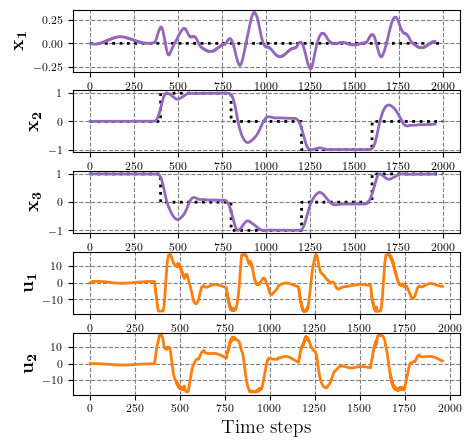

In [30]:
uvec1 = np.array(uvec1)
uvec2 = np.array(uvec2)
xvec = np.array(xvec)

# Paper Fig. 14: pitch, and the sine and cosine of the yaw, each tracking a
# dotted reference, over the two motor voltages.
fig_aero2(
    xref_traj[:, :3], xvec[:, :3], np.column_stack([uvec1, uvec2]),
    save_to="figures/Mamba-MPC_Aero2_N44_40Hz",
)
plt.show()